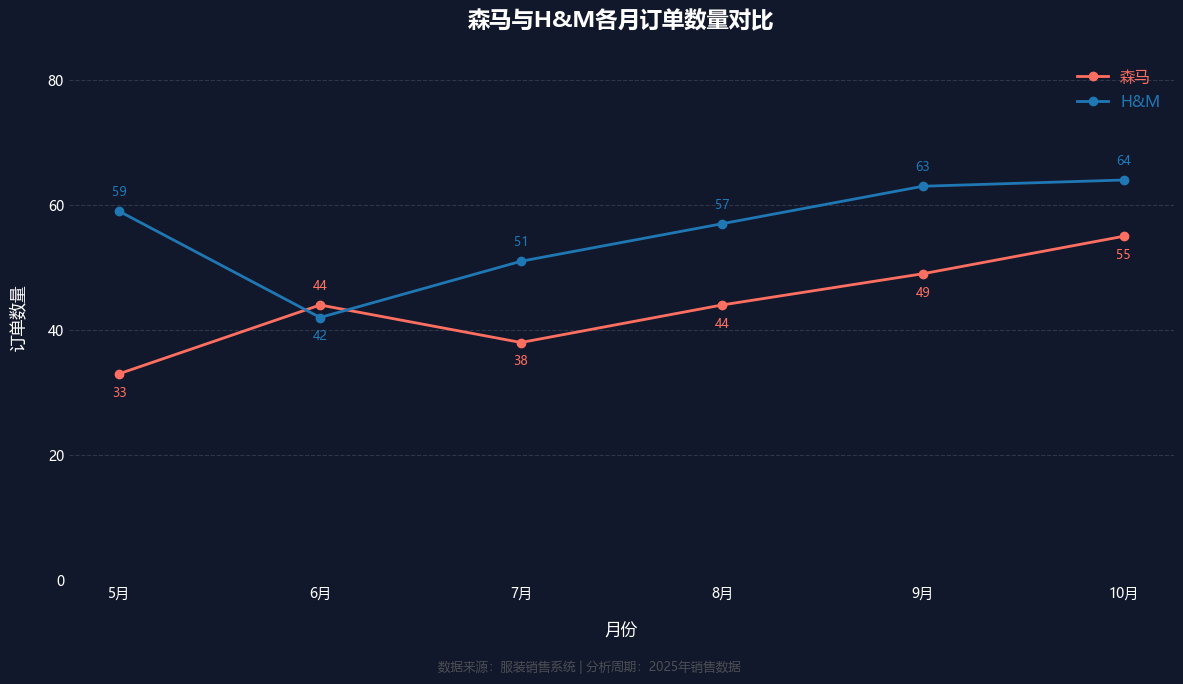

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取数据
    df_orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig', parse_dates=['下单时间'])
    
    # 提取与“森马”和“H&M”相关的订单
    semir_orders = df_orders[df_orders['店铺名称'].str.contains("森马")].copy()
    hm_orders = df_orders[df_orders['店铺名称'].str.contains("H&M")].copy()
    
    # 转换订单时间为月份
    semir_orders['月份'] = semir_orders['下单时间'].dt.to_period('M').astype(str)
    hm_orders['月份'] = hm_orders['下单时间'].dt.to_period('M').astype(str)
    
    # 按月统计订单笔数
    semir_monthly_counts = semir_orders.groupby('月份').size().sort_index()
    hm_monthly_counts = hm_orders.groupby('月份').size().sort_index()
    
    # 确保两个系列的月份对齐
    all_months = sorted(set(semir_monthly_counts.index).union(hm_monthly_counts.index))
    semir_monthly_counts = semir_monthly_counts.reindex(all_months, fill_value=0)
    hm_monthly_counts = hm_monthly_counts.reindex(all_months, fill_value=0)

    # 创建折线图
    fig, ax = plt.subplots(figsize=(13, 7), dpi=100)
    fig.patch.set_facecolor('#12182B')  # 深蓝色背景
    ax.set_facecolor('#12182B')

    # 绘制森马线条
    ax.plot(semir_monthly_counts.index, semir_monthly_counts, label='森马', marker='o', color='#FF6F61', linewidth=2)

    # 绘制H&M线条
    ax.plot(hm_monthly_counts.index, hm_monthly_counts, label='H&M', marker='o', color='#1F77B4', linewidth=2)
    
    # 添加数据标注
    for i, (semir_value, hm_value) in enumerate(zip(semir_monthly_counts, hm_monthly_counts)):
        semir_va = 'bottom' if semir_value > hm_value else 'top'
        hm_va = 'bottom' if hm_value > semir_value else 'top'
        
        ax.text(i, semir_value + (2 if semir_va == 'bottom' else -2), f'{semir_value}', color='#FF6F61', fontsize=9, ha='center', va=semir_va)
        ax.text(i, hm_value + (2 if hm_va == 'bottom' else -2), f'{hm_value}', color='#1F77B4', fontsize=9, ha='center', va=hm_va)

    # 设置标题和标签
    plt.title('森马与H&M各月订单数量对比', fontsize=16, fontweight='bold', color='#ffffff', pad=20)
    plt.xlabel('月份', fontsize=12, color='#ffffff', labelpad=15)
    plt.ylabel('订单数量', fontsize=12, color='#ffffff', labelpad=15)
    
    # 添加数据来源说明
    plt.figtext(
        0.5, 0.02,
        '数据来源：服装销售系统 | 分析周期：2025年销售数据',
        ha='center', fontsize=9, color='#666666', alpha=0.7
    )
    
    # 设置刻度和网格
    plt.xticks(ticks=np.arange(len(all_months)), labels=[f"{int(m.split('-')[1])}月" for m in all_months], color='#ffffff')
    plt.yticks(np.arange(0, max(semir_monthly_counts.max(), hm_monthly_counts.max()) + 20, 20), color='#ffffff')  # 固定间隔20
    ax.set_ylim(0, max(semir_monthly_counts.max(), hm_monthly_counts.max()) + 20)  # 缩小y轴高度
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='#777b92')

    # 移除轴的刻度线
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=0)
    
    # 添加图例并设置字体颜色
    legend = plt.legend(loc='upper right', fontsize=11, frameon=False, facecolor="#0a192f", edgecolor="#0a192f")
    for text, color in zip(legend.get_texts(), ['#FF6F61', '#1F77B4']):
        text.set_color(color)

    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)

    # 调整布局
    plt.subplots_adjust(bottom=0.15, top=0.9, left=0.1, right=0.95)

    # 保存图表
    plt.savefig('森马与H&M各月订单数量对比.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    # 显示图表
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")

# 分析：

- **森马**：
  森马的订单数量在整个时间段内呈现持续增长的趋势，特别是在5月到10月期间，其订单量从33增加到55，显示出其在市场中的稳步增长和持续吸引消费者的能力。6月订单数量略高于H&M，显示出此时竞争明显。

- **H&M**：
  H&M的订单数量在图中显示出由高到低再逐步回升的趋势，其订单量从59下降至42然后稳步上升至64，尤其是从7月到10月保持上升，可能表明其在下半年推出了吸引消费者的策略或者产品。其在图中显示出的波动性表明市场策略可能存在调整。


# 结论：

从订单数量的变化趋势来看，森马逐月订单增长较为稳健，显示出其较强的市场吸引力和稳定的消费者群体。而H&M虽然开场的订单数量较高，但经历了一段时间的下降后反弹至更高水平，显示出其策略调整后的有效性。两者在所分析的周期内显示出市场竞争的动态变化，值得进一步研究在特定月份进行的促销活动或者市场策略。整体市场情况显示，订单量的增加可能与消费者偏好的变化及品牌的市场策略密切相关。